In [17]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from numba import njit, prange

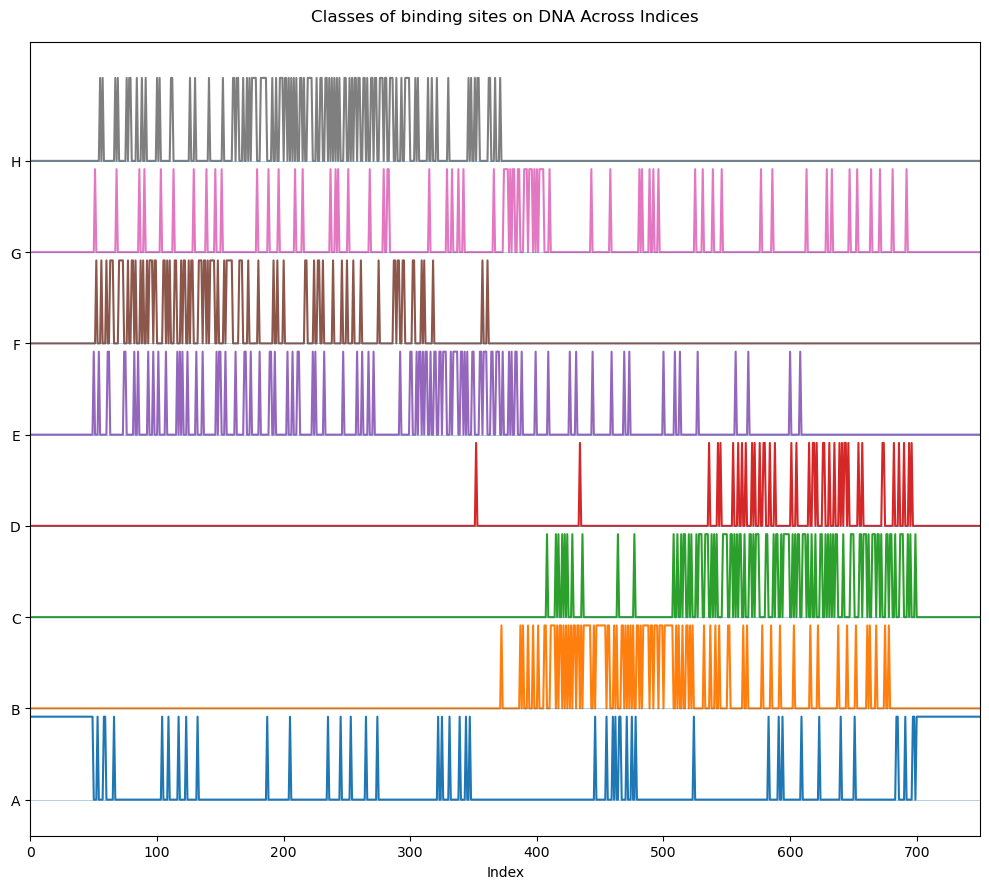

In [2]:
ns = 750
chain_interaction_binary = IMR90_data(ns, split_class_zero=False)

In [3]:
from joblib import Parallel, delayed
from itertools import product

def single_run(Chi_N):

    chi_pp = Chi_N*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
    chi_ps = Chi_N*xp.ones(chain_interaction_binary.shape[0])

    N = 1000

    nx = ny = 128
    initial_qsr = xp.ones((nx, ny))
    L = 56 #dimension of the box

    boundary = xp.random.rand(nx,ny)

    polymer = Scft(
        N = N,
        Lx=L, Ly=L,
        phibar=0.1, # volume fraction of polymer
        l_p=xp.sqrt(N),
        n_seg=1, # contour length of polymer normalized from 0-1
        nx=nx, ny=ny,
        ns=ns,
        iterations=10000,
        error_tol=1e-12,
        chain_interaction=xp.asarray(chain_interaction_binary),
        self_avoiding=0,
        initial_qsr=xp.array(boundary),
        mixing_rate=0.005,
        chi_polymer_block = chi_pp,
        chi_polymer_s = chi_ps,
        PB = 1,
        close_boundary=True,
    )

    wsr, qsr_initial, qsr_d_initial, diff = initialization(polymer, shift = 15, seed = 5652)
    wsr, phi, phi_blocks, qsr, qsr_d, diff = scft_loop_return_qsr(polymer, wsr, qsr_initial, qsr_d_initial, diff)

    return to_numpy(phi_blocks), to_numpy(qsr), diff

def parameter_sweep_2d(n_jobs=3, backend="loky", seed=5):
    ChiNs = np.array([350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900])

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(single_run)(Chi_N) for (Chi_N) in
        tqdm(ChiNs, total = len(ChiNs))
    )
    phi_block_list, qsr_list, diff_list = zip(*results)

    return phi_block_list, qsr_list, diff_list


In [4]:
ChiNs = np.array([350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900])
phi_blocks_grid, qsr_grid, diff_grid = parameter_sweep_2d()
np.save("phi_blocks_grid", phi_blocks_grid)
np.save("qsr_grid", qsr_grid)
np.save("diff_grid", diff_grid)

  0%|          | 0/12 [00:00<?, ?it/s]

In [6]:
phi_blocks_grid = np.array(phi_blocks_grid)
print(phi_blocks_grid.shape)
print(phi_blocks_grid[0,0].shape)

diff_grid = np.array(diff_grid)
print(diff_grid.shape)

(12, 8, 128, 128)
(128, 128)
(12, 10000)


900


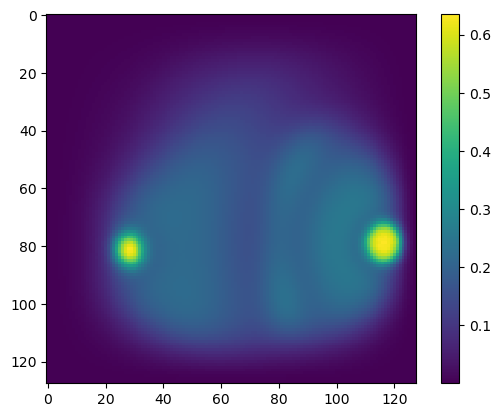

In [23]:
idx = -1
print(ChiNs[idx])
phi = np.sum(phi_blocks_grid[idx], axis=0)
plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

In [18]:
@njit(parallel=True)
def pair_correlation_2D_vectorized_numba(rho):
    ns_plus_1, nx, ny = rho.shape
    correlation_function = np.zeros((ns_plus_1, ns_plus_1))

    # 2) Double loop over segment indices in parallel
    for i in prange(ns_plus_1):
        for k in prange(ns_plus_1):
            # Sum over x, y in one go:
            correlation_function[i, k] = np.sum(rho[i] * rho[k])

    # 3) Divide by (nx*ny)
    correlation_function /= (nx * ny)

    # 4) Subtract mean
    return correlation_function - np.mean(correlation_function)

In [19]:
corr_2d = pair_correlation_2D_vectorized_numba(to_numpy(qsr*qsr_d))
dynamic_range = 1.8 * np.std(corr_2d)
plt.imshow(corr_2d, cmap='viridis', interpolation='nearest', aspect=1,
           #vmin=-dynamic_range,
           vmax=+dynamic_range
           )

NameError: name 'qsr' is not defined

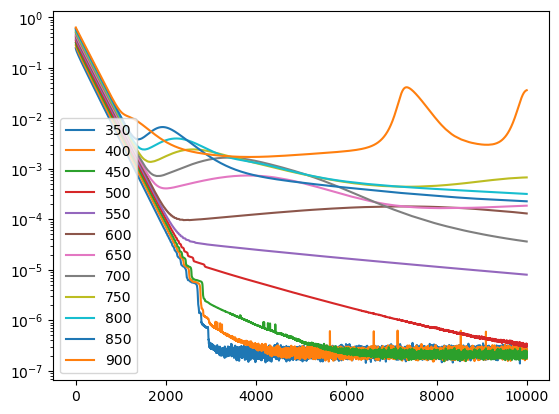

In [8]:
ChiNs = np.array([350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900])
for i in range(diff_grid.shape[0]):
    plt.plot(diff_grid[i,:], label=str(ChiNs[i]))
plt.legend()
plt.yscale("log")

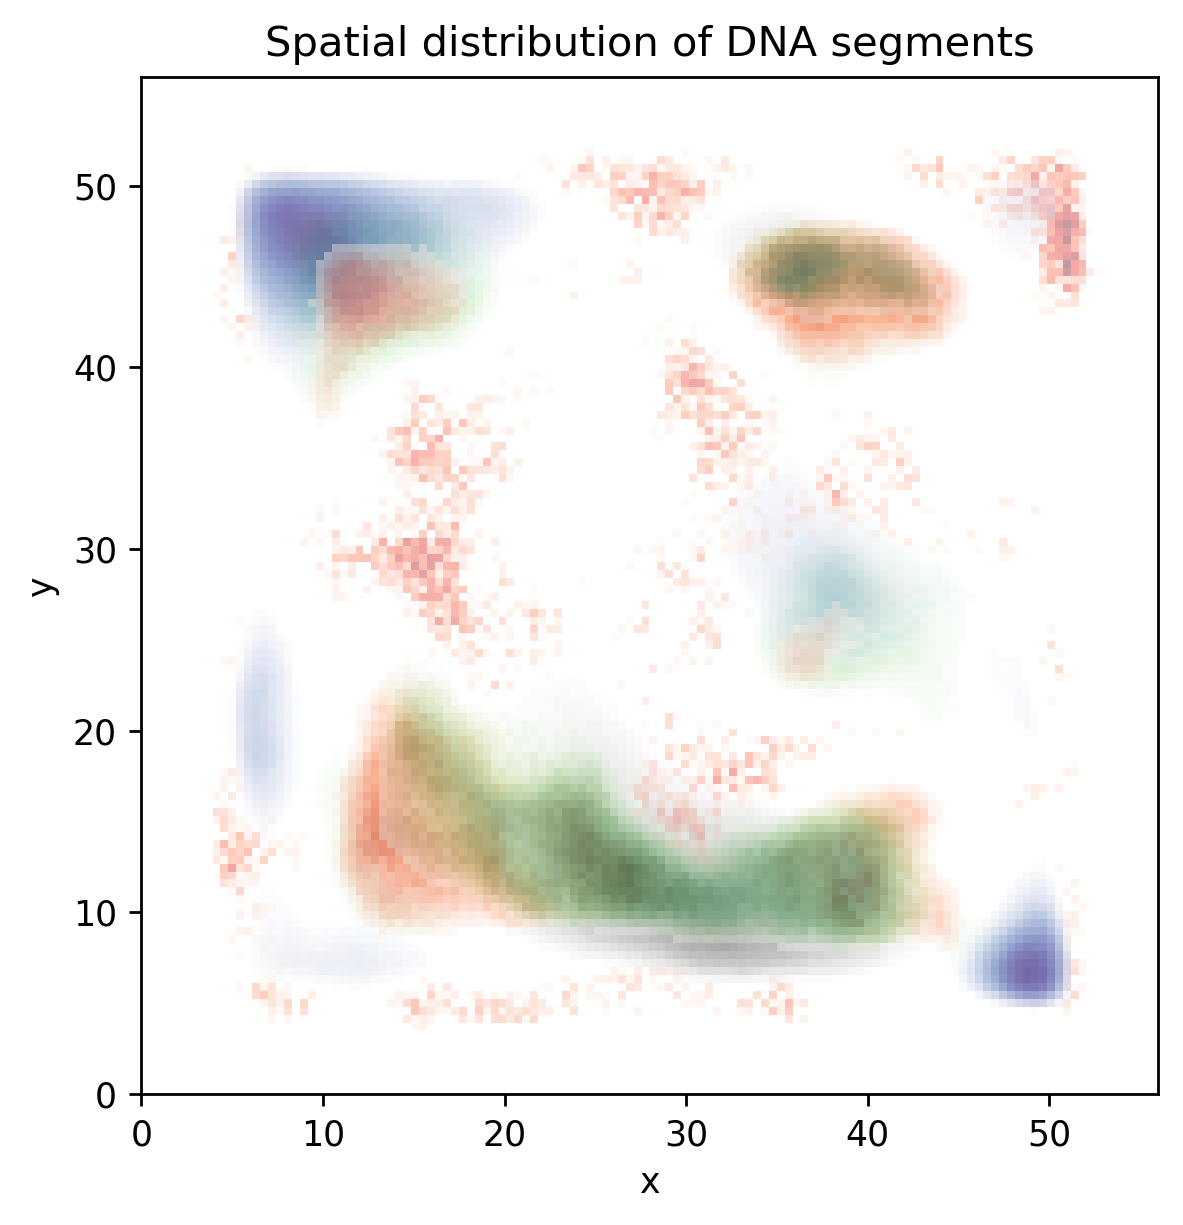

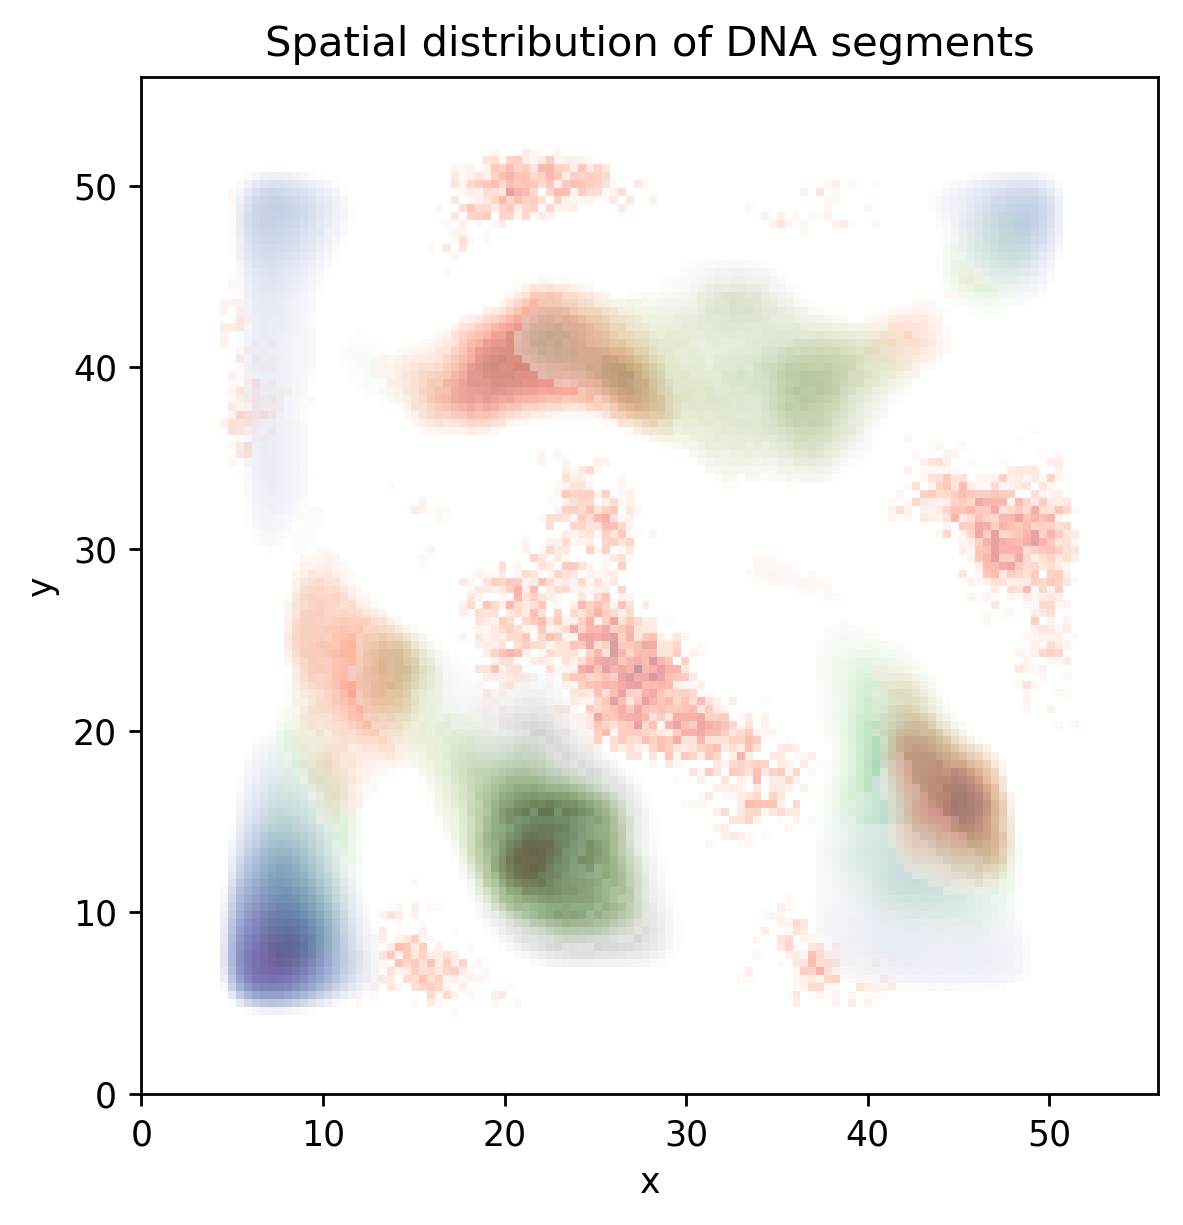

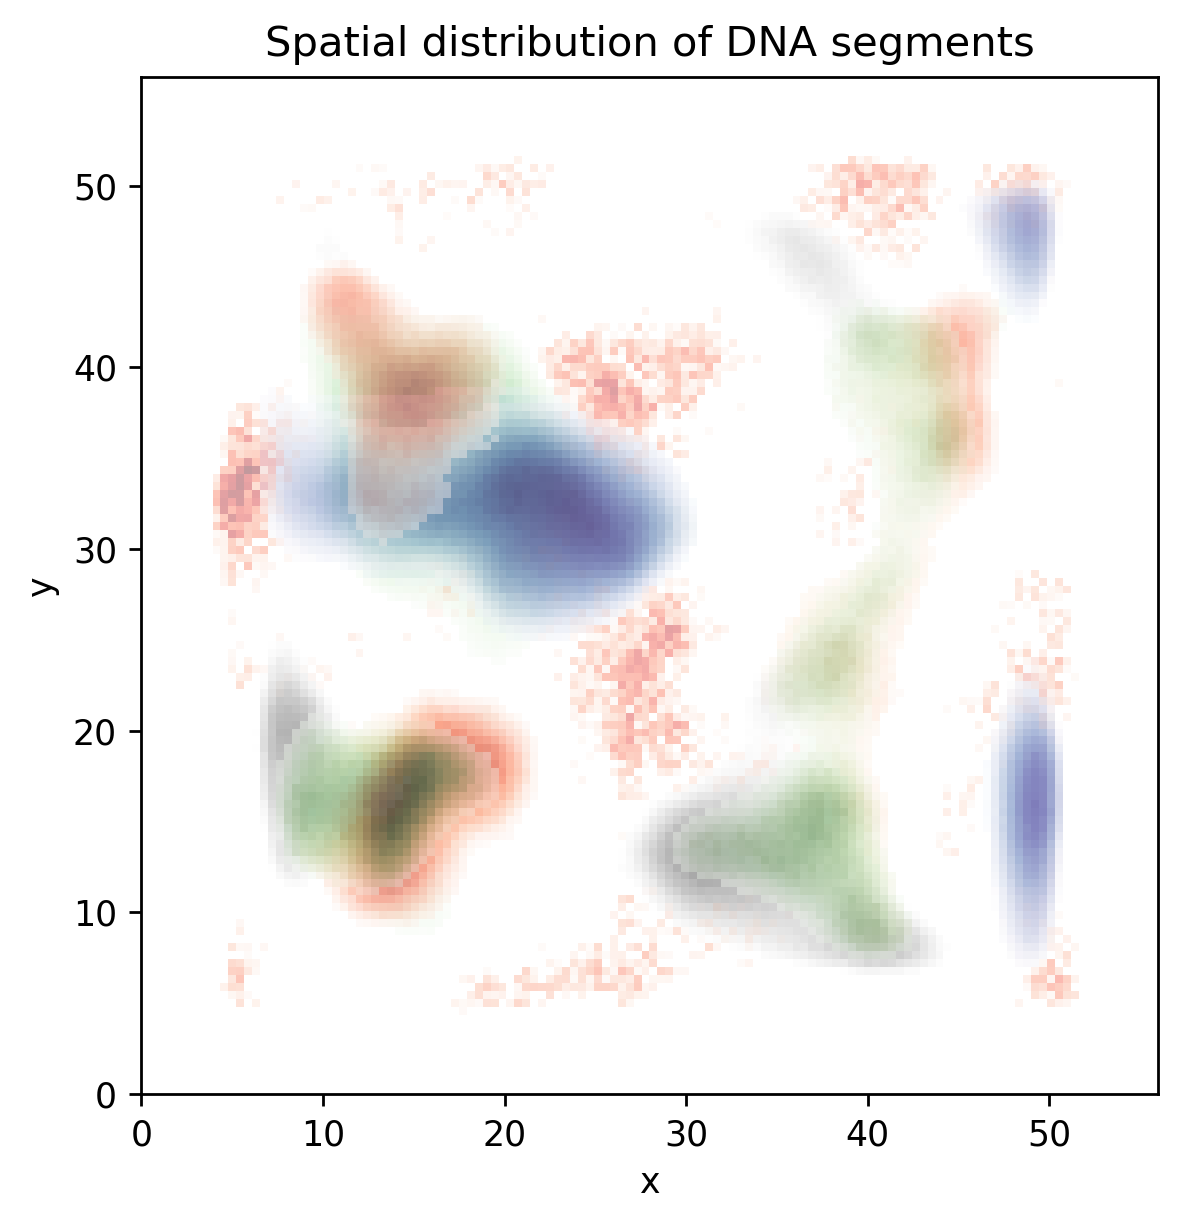

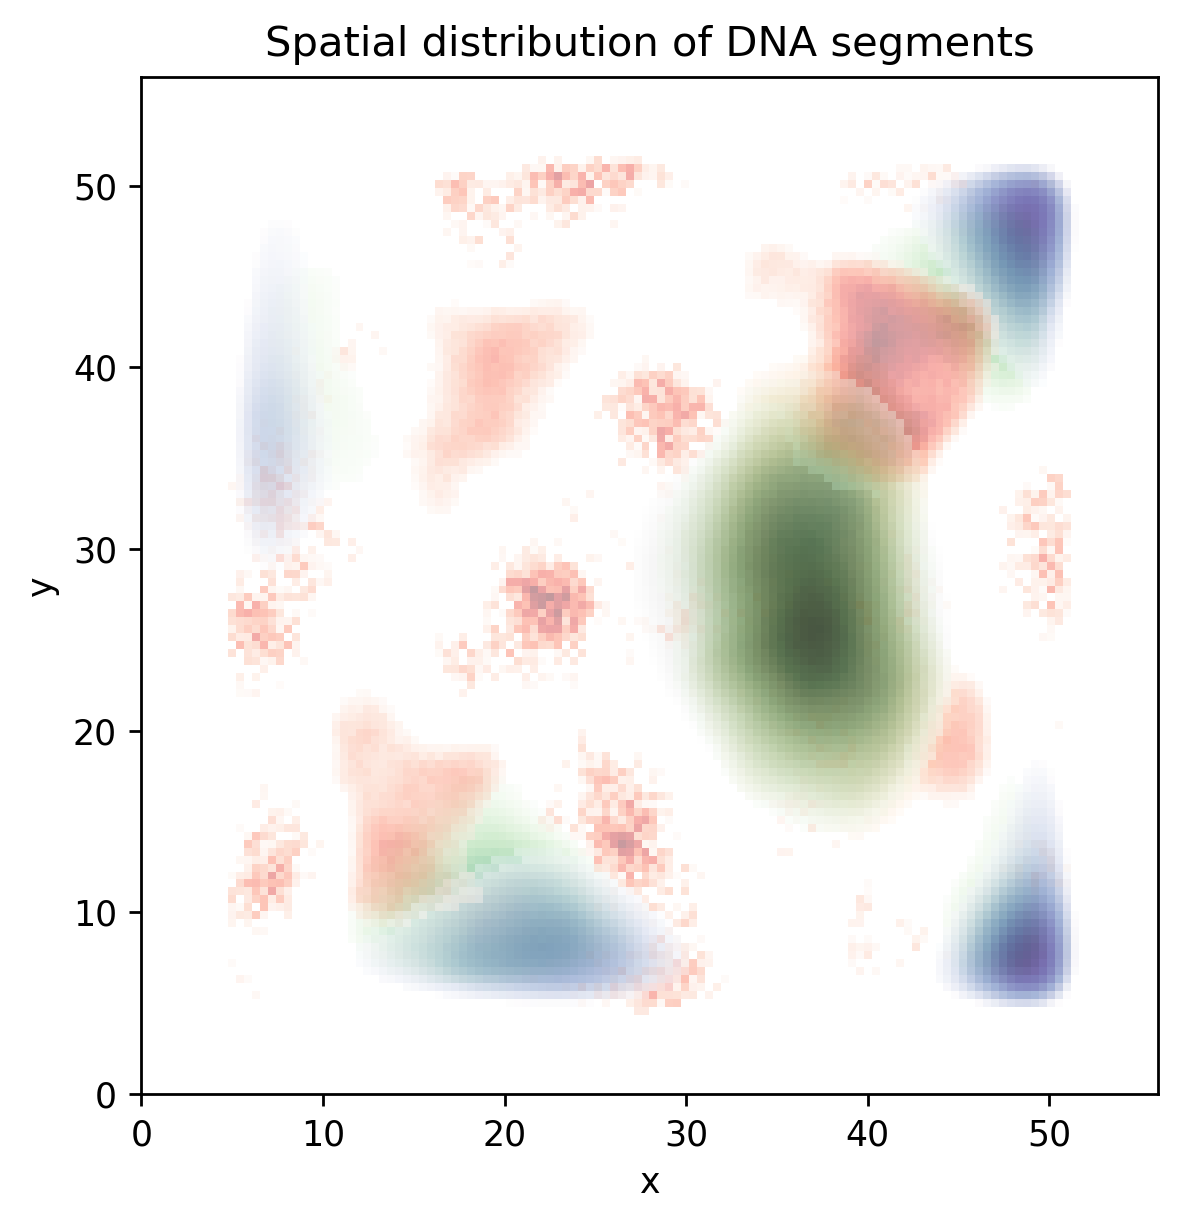

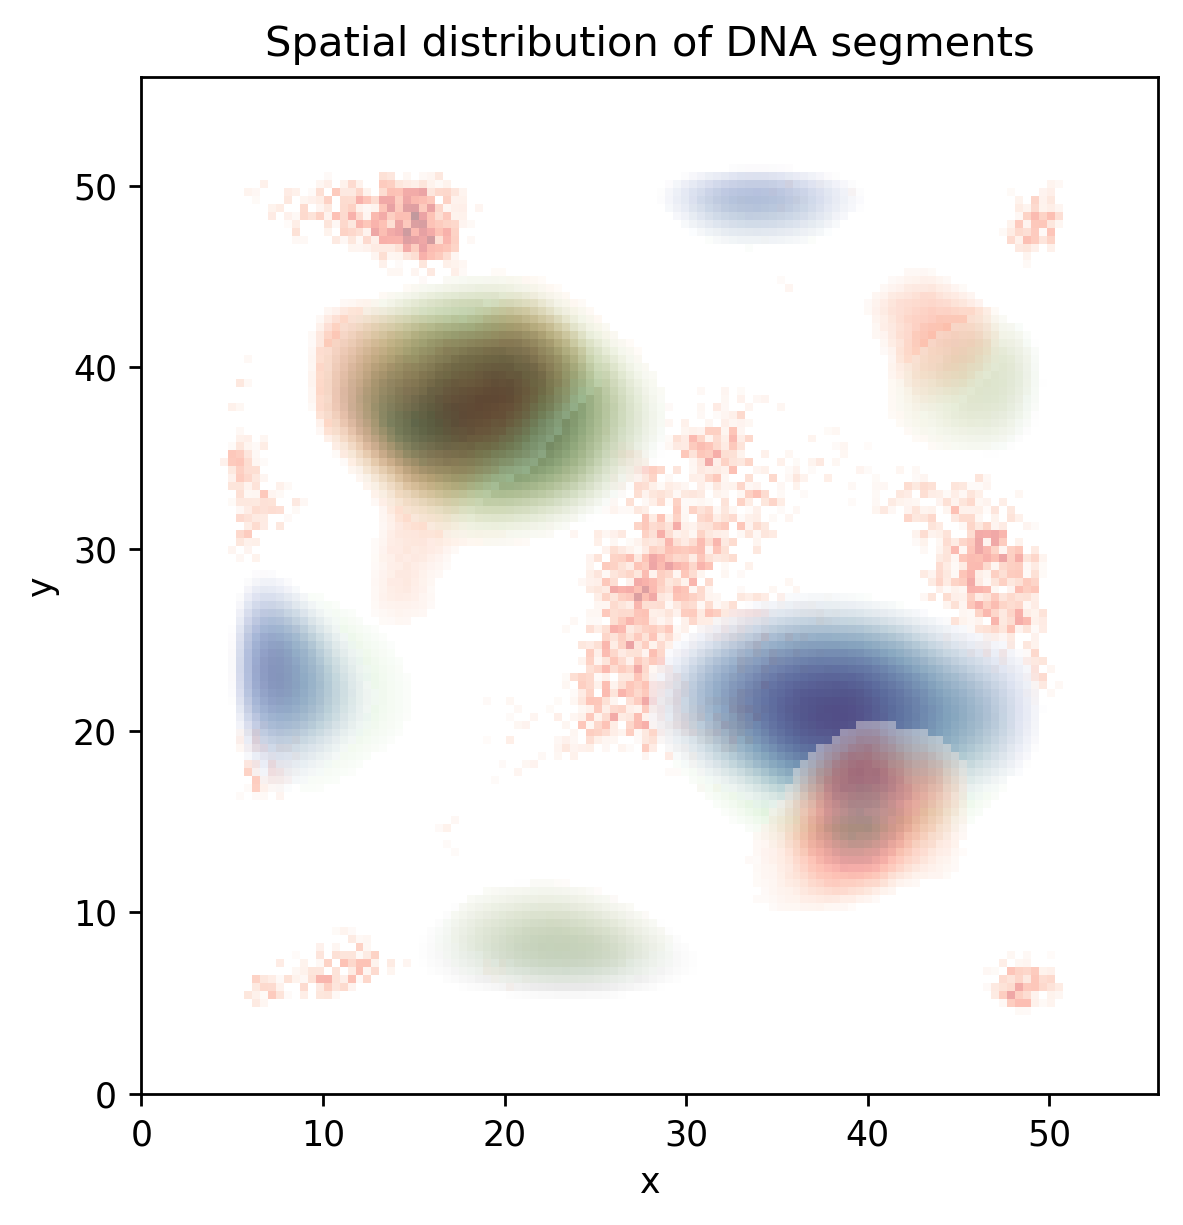

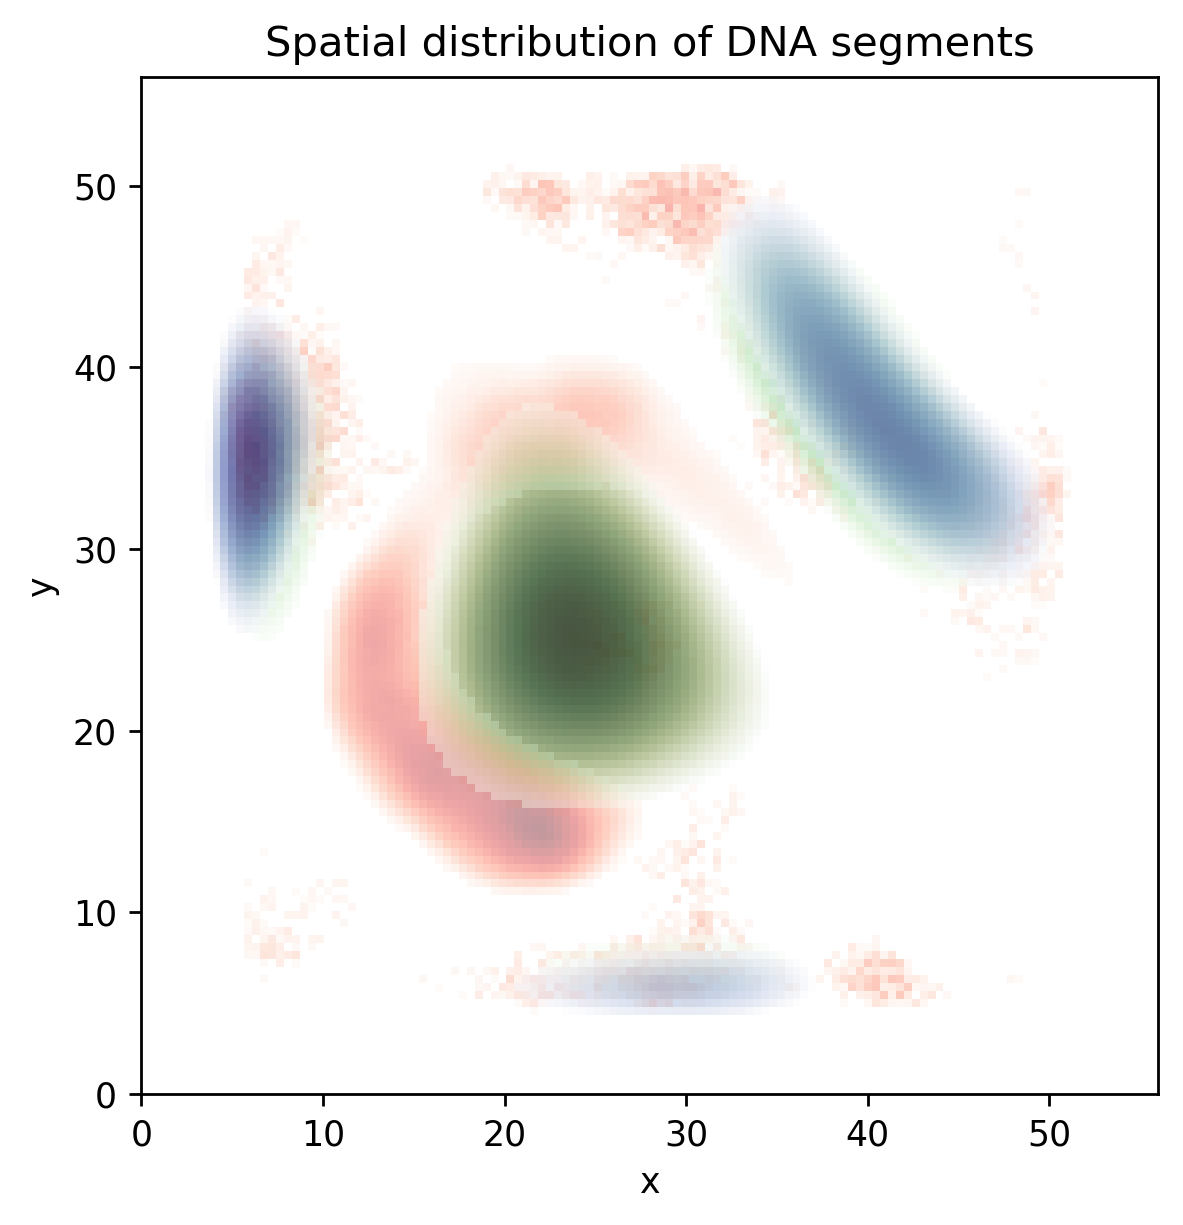

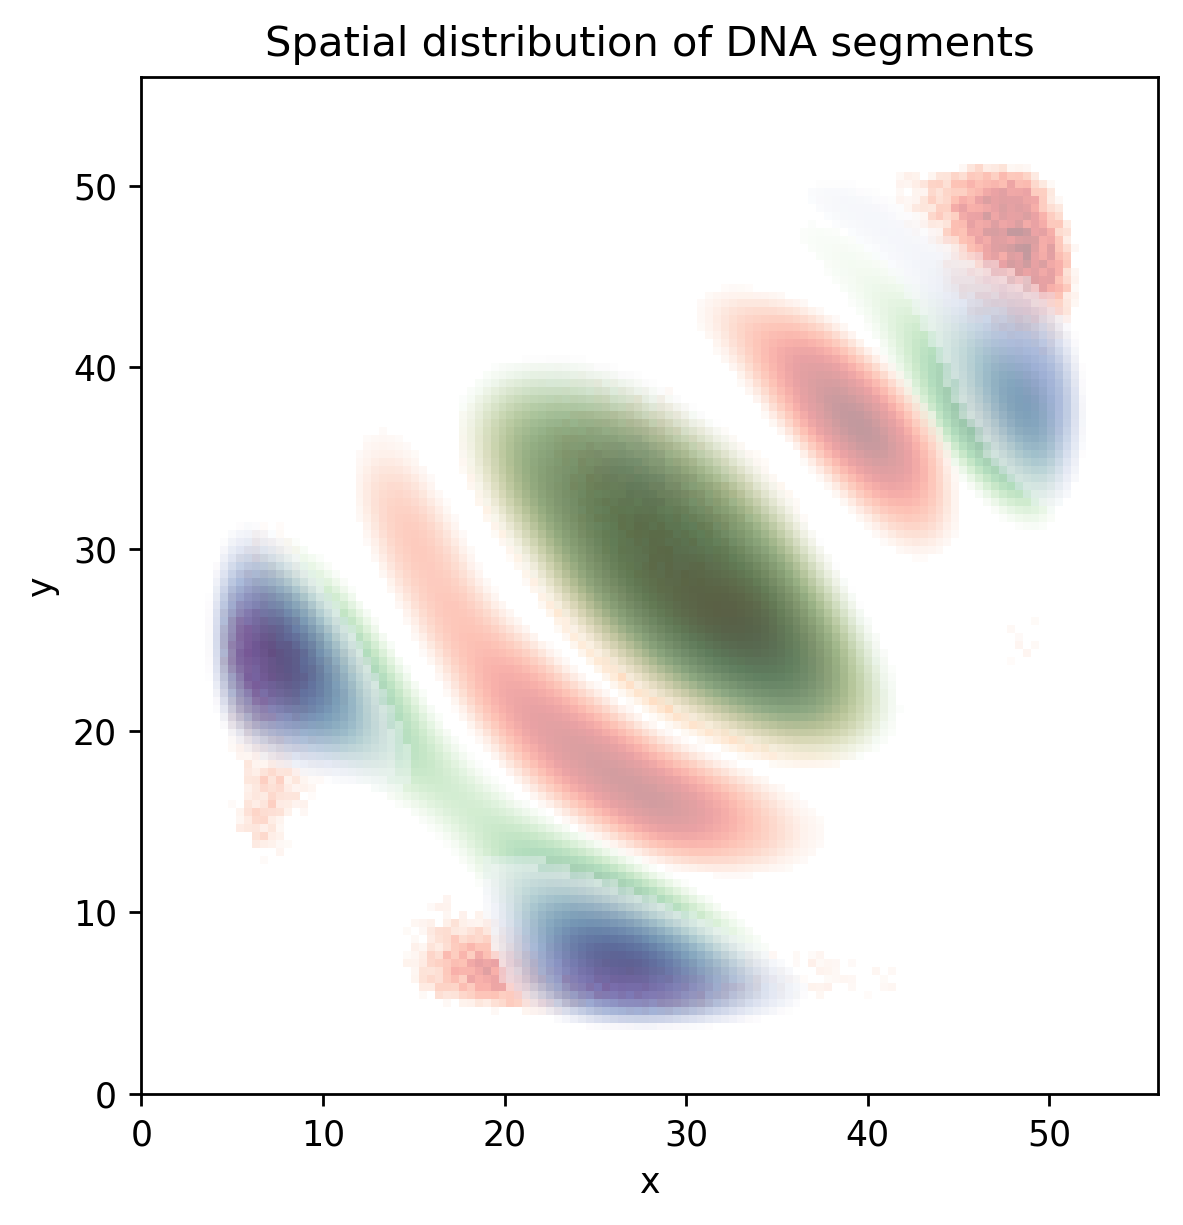

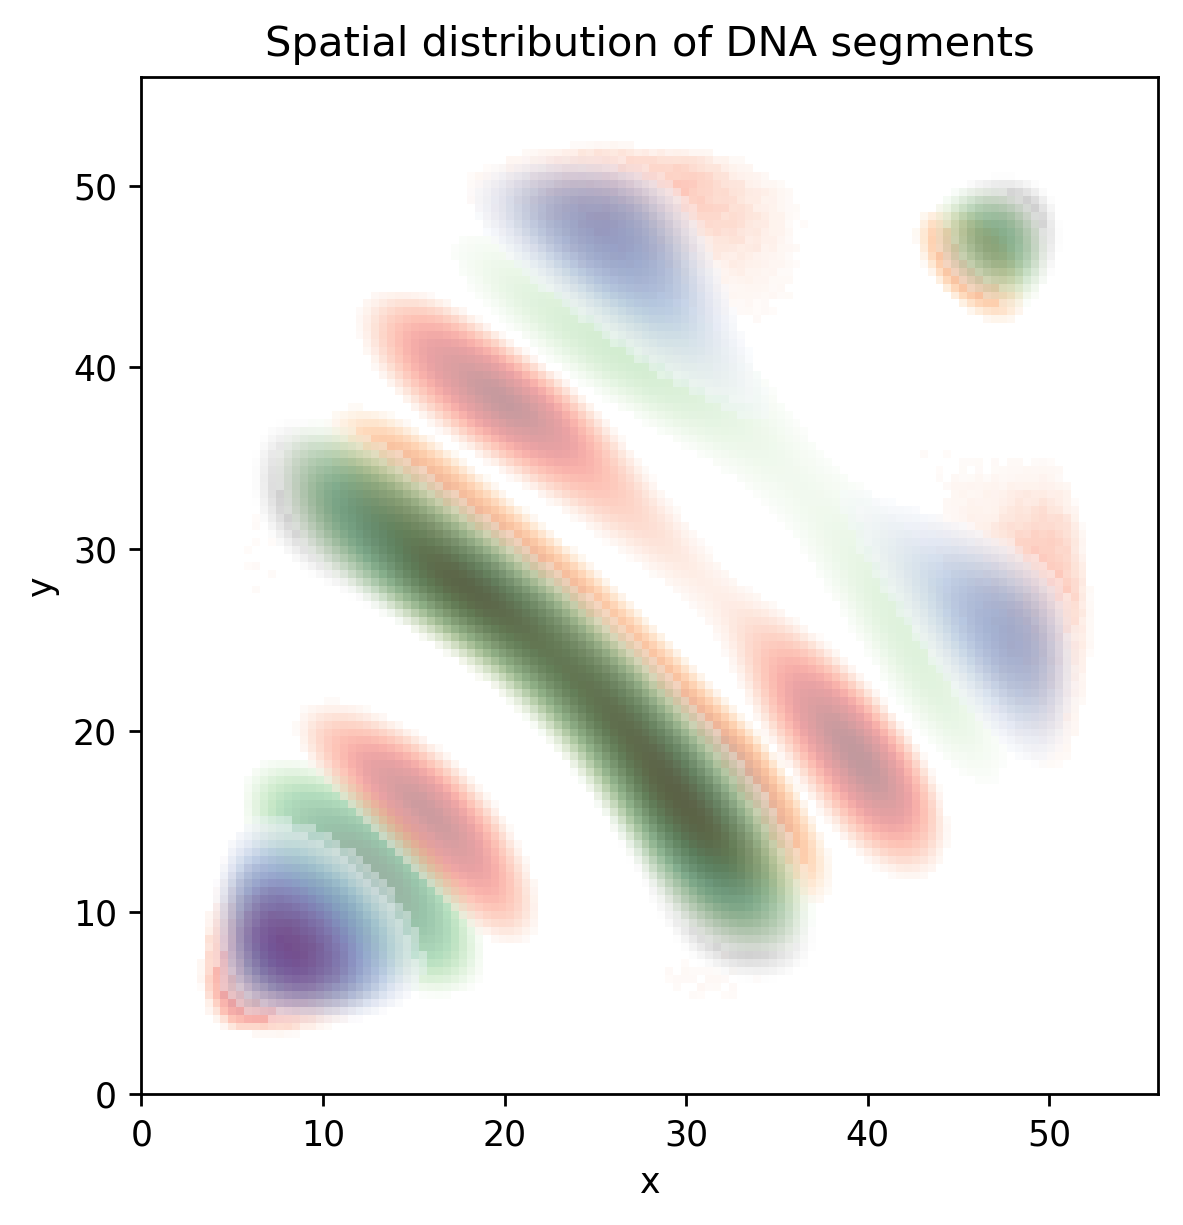

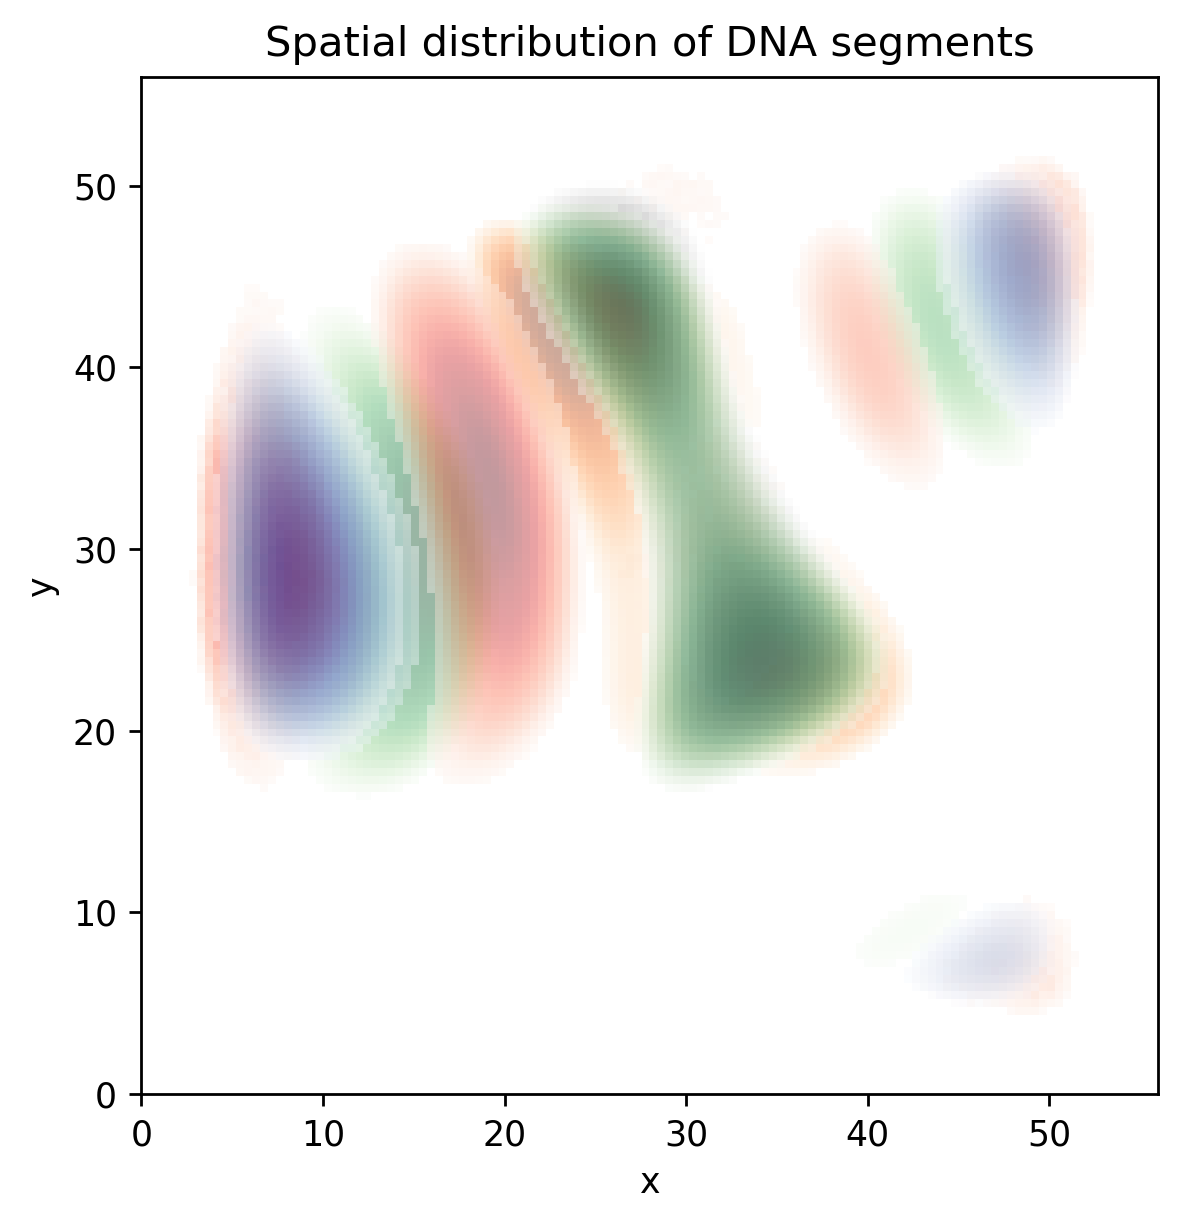

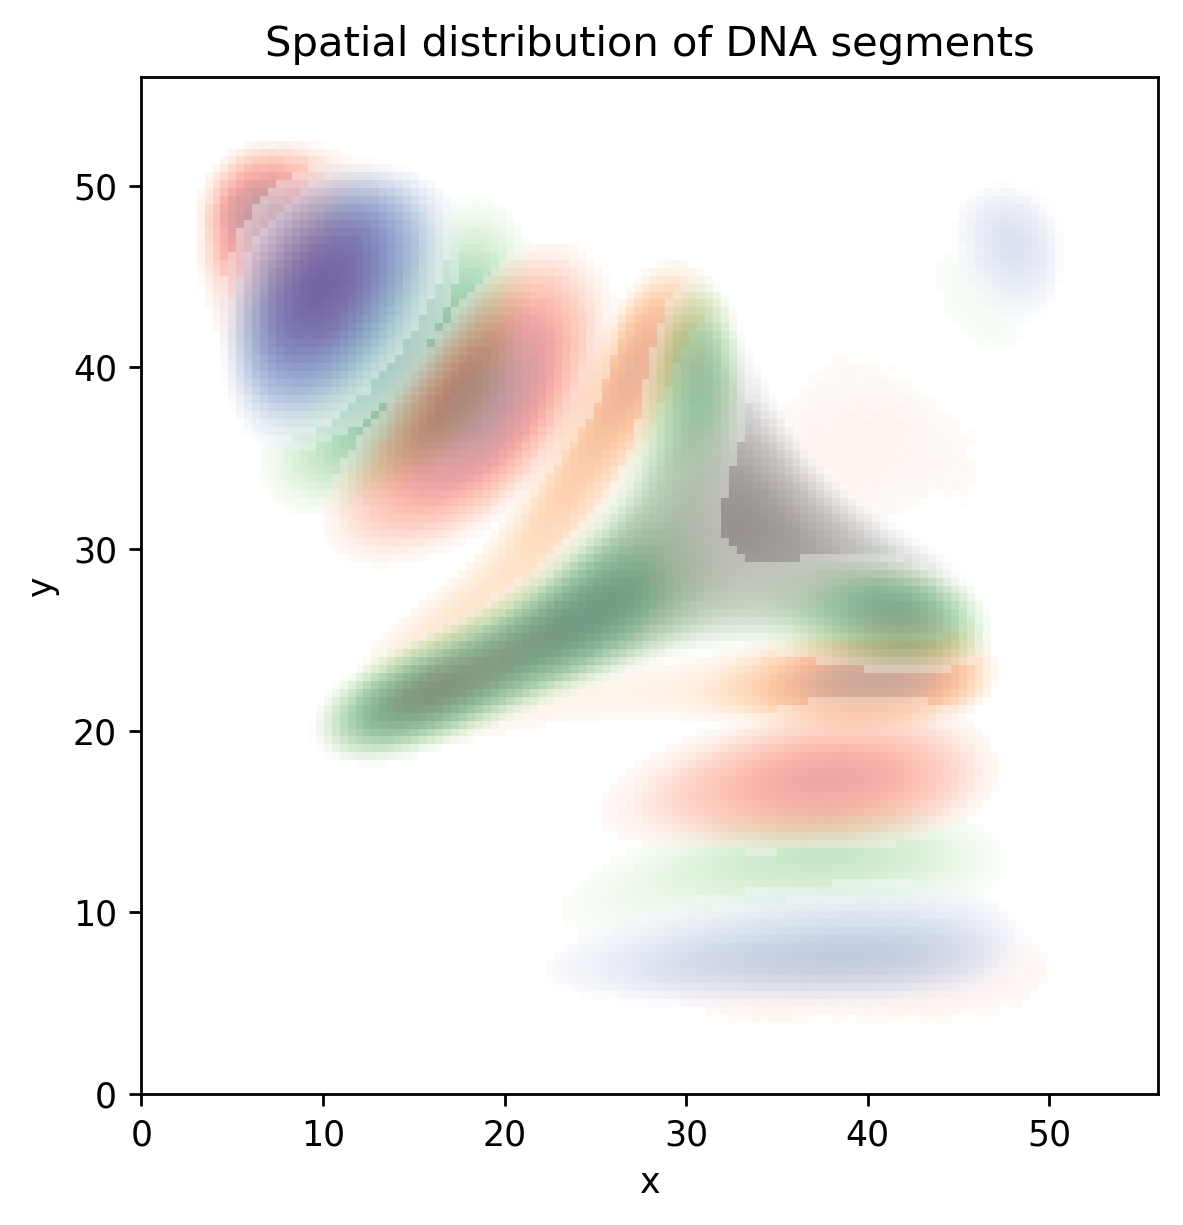

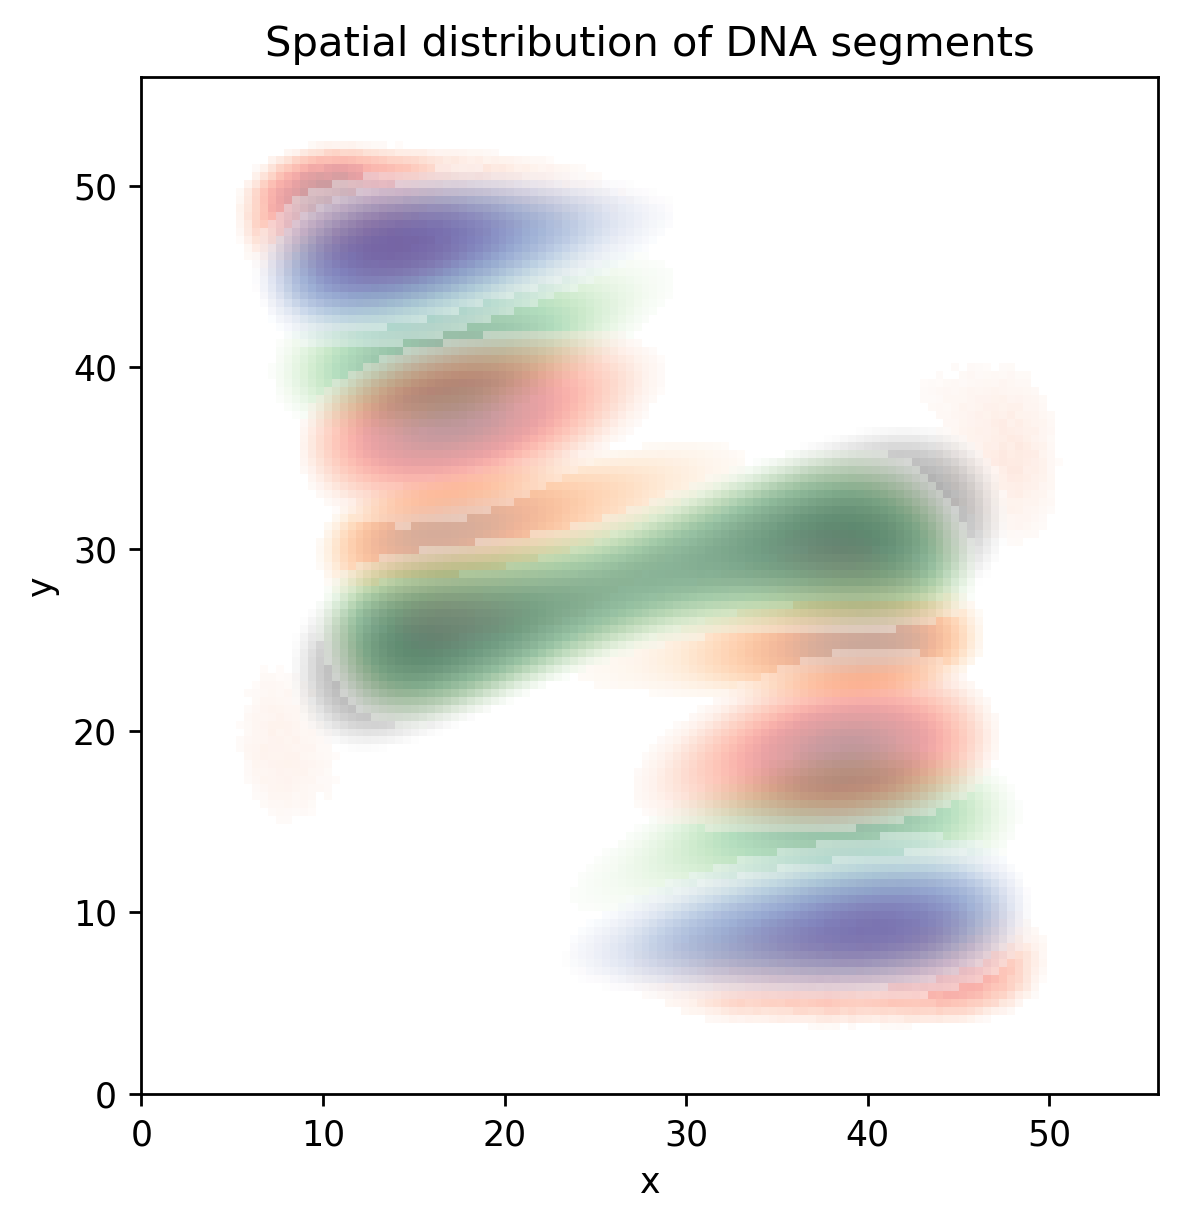

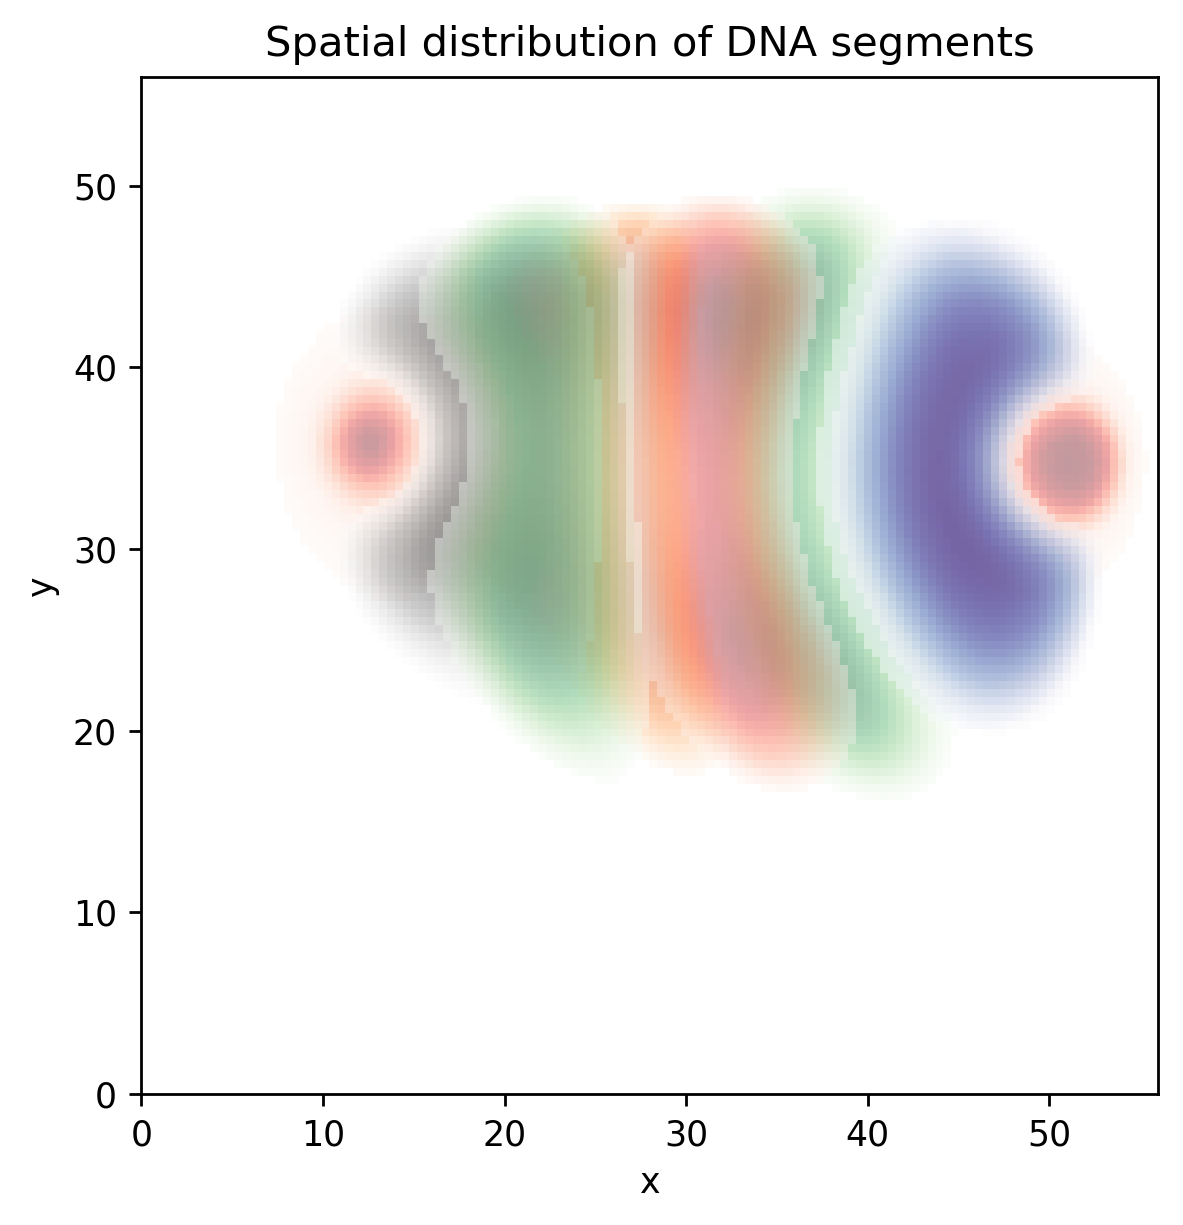

In [11]:
for i in range(diff_grid.shape[0]):
    plot_phi_blocks_periodic(phi_blocks_grid[i], extent=(0, 56, 0, 56), percentile=90, shift_x=0, shift_y=0)